# Jeremy SOLPS cases: plasma, strip profiles, and full OpenEdge runs

This notebook keeps the full Jeremy workflow in one place:

1. build `plasma_<case>.h5` for selected SOLPS cases,
2. generate case-named outer-divertor strip CSVs,
3. create case-specific `.surf` files with `Tsurf_lm` and `Gamma_D_lm`,
4. run a full OpenEdge droplet case for each plasma background,
5. overlay the resulting wall-source profiles across cases.


In [468]:
from __future__ import annotations

import math
import shlex
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plotter

EXAMPLE_ROOT = Path("/Users/42d/OpenEdge/examples/test_tsurf_emission").resolve()
CASE_ROOT = Path("/Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)").resolve()
BASERUN_DIR = CASE_ROOT / "baserun"
EQU_FILE = BASERUN_DIR / "dg.equ"
B2FGMTRY_FILE = BASERUN_DIR / "b2fgmtry"

CONVERTER = (EXAMPLE_ROOT / "../../tools/converters/convert_solps_plasma.py").resolve()
PYTHON_EXE = Path(sys.executable).resolve()
OPENEDGE_BIN = Path("/Users/42d/OpenEdge/build/src/spa_mac_mpi").resolve()
SHARED_SURF = EXAMPLE_ROOT / "input" / "divertor_slab.surf"

GENERATED_ROOT = EXAMPLE_ROOT / "jeremy_cases_generated"
PLASMA_DIR = GENERATED_ROOT / "plasma"
STRIP_RUNS_DIR = GENERATED_ROOT / "runs"
STRIP_DIR = GENERATED_ROOT / "strip_csv"
SURF_DIR = GENERATED_ROOT / "surf_with_strip"
FULL_RUNS_DIR = GENERATED_ROOT / "full_runs"

for path in [GENERATED_ROOT, PLASMA_DIR, STRIP_RUNS_DIR, STRIP_DIR, SURF_DIR, FULL_RUNS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

def run_cmd(cmd: list[str], cwd: Path | None = None) -> None:
    print("+", " ".join(shlex.quote(part) for part in cmd))
    subprocess.run(cmd, cwd=cwd, check=True)

def stage_ld_tg_o(run_dir: Path, source_file: Path) -> Path:
    link = run_dir / "ld_tg_o.dat"
    if link.exists() or link.is_symlink():
        link.unlink()
    link.symlink_to(source_file)
    return link

run_cmd([str(PYTHON_EXE), "-c", "import h5py, scipy, pandas, matplotlib; print('python deps: OK')"])

print(f"Example root : {EXAMPLE_ROOT}")
print(f"Case root    : {CASE_ROOT}")
print(f"Baserun      : {BASERUN_DIR}")
print(f"Equilibrium  : {EQU_FILE}")
print(f"b2fgmtry     : {B2FGMTRY_FILE}")
print(f"Converter    : {CONVERTER}")
print(f"Python exe   : {PYTHON_EXE}")
print(f"OpenEdge bin : {OPENEDGE_BIN}")
print(f"Shared surf  : {SHARED_SURF}")


+ /Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/bin/python3.9 -c 'import h5py, scipy, pandas, matplotlib; print('"'"'python deps: OK'"'"')'
python deps: OK
Example root : /Users/42d/OpenEdge/examples/test_tsurf_emission
Case root    : /Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)
Baserun      : /Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)/baserun
Equilibrium  : /Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)/baserun/dg.equ
b2fgmtry     : /Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)/baserun/b2fgmtry
Converter    : /Users/42d/OpenEdge/tools/converters/convert_solps_plasma.py
Python exe   : /Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/bin/python3.9
OpenEdge bin : /Users/42d/OpenEdge/build/src/spa_mac_mpi
Shared surf  : /Users/42d/OpenEdge/examples/test_tsurf_emission/input/divertor_slab.surf


## Select cases

Edit `SELECTED_CASES` to control which Jeremy runs are processed.

In [411]:
SELECTED_CASES = [
    "P90MW_core_1e22_chi_0.3_D_0.1",
    "P90MW_core_1e22_chi_0.3_D_0.1_ne1",
    "P90MW_core_1e22_chi_0.3_D_0.1_ne4",
    "P90MW_core_1e22_chi_0.3_D_0.1_ne10",
]

rows = []
for case in SELECTED_CASES:
    case_dir = CASE_ROOT / case
    rows.append({
        "case": case,
        "case_dir": str(case_dir),
        "b2fstate": (case_dir / "b2fstate").exists(),
        "b2fstate_size": (case_dir / "b2fstate").stat().st_size if (case_dir / "b2fstate").exists() else -1,
        "b2fgmtry_shared": B2FGMTRY_FILE.exists(),
        "ld_tg_o": (case_dir / "WLLD" / "ld_tg_o.dat").exists(),
    })

pd.DataFrame(rows)


,case,case_dir,b2fstate,b2fstate_size,b2fgmtry_shared,ld_tg_o
0,P90MW_core_1e22_chi_0.3_D_0.1,/Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)/P...,True,94189312,True,True
1,P90MW_core_1e22_chi_0.3_D_0.1_ne1,/Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)/P...,True,94189312,True,True
2,P90MW_core_1e22_chi_0.3_D_0.1_ne4,/Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)/P...,True,94189312,True,True
3,P90MW_core_1e22_chi_0.3_D_0.1_ne10,/Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)/P...,True,94189312,True,True


## Build `plasma_<case>.h5`

This reuses the shared `baserun/b2fgmtry` and `baserun/dg.equ`, while taking each case's `b2fstate` as the plasma state.

In [469]:
for case in SELECTED_CASES:
    case_dir = CASE_ROOT / case
    plasma_out = PLASMA_DIR / f"plasma_{case}.h5"
    cmd = [
        str(PYTHON_EXE),
        str(CONVERTER),
        str(case_dir),
        "--b2fgmtry", str(B2FGMTRY_FILE),
        "--b2fstate", str(case_dir / "b2fstate"),
        "--equ-file", str(EQU_FILE),
        "--plasma-out", str(plasma_out),
        "--wall-in", str(SHARED_SURF),
        "--geometry", "cart",
    ]
    run_cmd(cmd, cwd=EXAMPLE_ROOT)

sorted(str(p.name) for p in PLASMA_DIR.glob("plasma_*.h5"))


+ /Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/bin/python3.9 /Users/42d/OpenEdge/tools/converters/convert_solps_plasma.py '/Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)/P90MW_core_1e22_chi_0.3_D_0.1' --b2fgmtry '/Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)/baserun/b2fgmtry' --b2fstate '/Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)/P90MW_core_1e22_chi_0.3_D_0.1/b2fstate' --equ-file '/Users/42d/ORNL Dropbox/Abdou Diaw/addLi (1)/baserun/dg.equ' --plasma-out /Users/42d/OpenEdge/examples/test_tsurf_emission/jeremy_cases_generated/plasma/plasma_P90MW_core_1e22_chi_0.3_D_0.1.h5 --wall-in /Users/42d/OpenEdge/examples/test_tsurf_emission/input/divertor_slab.surf --geometry cart
SOLPS grid: nx=170, ny=36, ns=17
Species detected (17): ['D0', 'D+', 'Ne0', 'Ne+', 'Ne2+', 'Ne3+', 'Ne4+', 'Ne5+', 'Ne6+', 'Ne7+', 'Ne8+', 'Ne9+', 'Ne10+', 'Li0', 'Li+', 'Li2+', 'Li3+']
Charge states: [0, 1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0, 1, 2, 3]
Charged species: 14 (skipping

['plasma_P90MW_core_1e22_chi_0.3_D_0.1.h5',
 'plasma_P90MW_core_1e22_chi_0.3_D_0.1_ne1.h5',
 'plasma_P90MW_core_1e22_chi_0.3_D_0.1_ne10.h5',
 'plasma_P90MW_core_1e22_chi_0.3_D_0.1_ne4.h5']

## Generate case-named strip CSVs

This uses a minimal `run 0` OpenEdge deck with `fix surface/state/lm` and the case's `ld_tg_o.dat` to write `<case>.strip.csv` for the outer divertor.

In [413]:
STRIP_DECK_TEMPLATE = """
seed 1234 
dimension   2
boundary    o o p
global      gridcut 0.0 comm/sort no
timestep    5e-05

create_box  3.1 3.5 -3.8 -3.1 -0.05 0.05
create_grid 100 100 1
balance_grid rcb cell

read_surf   {surf} invert group slab particle check
group div_front surf id <> 1 199

surf_collide vac specular
surf_modify  slab collide vac

# fix pd back solps restand run_dir 


fix pd background file {plasma} static yes
fix flm_ol surface/state/lm div_front 1 solps_b2pl ld_tg_o.dat &
           h0 5.0e-3 U0 8.0 Bs 5.0 alpha 43.0 width 1.67 Tin 350.0 static yes csv {strip_csv}

stats       1
run         0
"""

strip_results = []

for case in SELECTED_CASES:
    run_dir = STRIP_RUNS_DIR / case
    run_dir.mkdir(parents=True, exist_ok=True)

    plasma_file = PLASMA_DIR / f"plasma_{case}.h5"
    ld_tg_o_src = CASE_ROOT / case / "WLLD" / "ld_tg_o.dat"
    strip_csv = STRIP_DIR / f"{case}.strip.csv"
    deck_path = run_dir / "in.strip_case"

    stage_ld_tg_o(run_dir, ld_tg_o_src)

    deck_text = STRIP_DECK_TEMPLATE.format(
        surf=SHARED_SURF,
        plasma=plasma_file,
        strip_csv=strip_csv,
    )
    deck_path.write_text(deck_text)

    run_cmd(["mpirun", "-np", "1", str(OPENEDGE_BIN), "-in", deck_path.name], cwd=run_dir)

    strip_results.append({
        "case": case,
        "plasma_h5": str(plasma_file),
        "strip_csv": str(strip_csv),
        "rows": sum(1 for _ in strip_csv.open()) - 1 if strip_csv.exists() else 0,
    })

pd.DataFrame(strip_results)


+ mpirun -np 1 /Users/42d/OpenEdge/build/src/spa_mac_mpi -in in.strip_case
SPARTA-OPENDGE (20 Jan 2025)
Running on 1 MPI task(s)
Created orthogonal box = (3.1 -3.8 -0.05) to (3.5 -3.1 0.05)
Created 10000 child grid cells
  CPU time = 0.001293 secs
  create/ghost percent = 32.4053 67.5947
Balance grid migrated 0 cells
  CPU time = 0.000673 secs
  reassign/sort/migrate/ghost percent = 26.7459 1.3373 9.50966 62.4071
Reading surface file ...
  202 lines
  3.38162 3.48677 xlo xhi
  -3.77748 -3.1105 ylo yhi
  0 0 zlo zhi
  0.00338702 min line length
  242 0 = cells overlapping surfs, overlap cells with unmarked corner pts
  9688 70 242 = cells outside/inside/overlapping surfs
  242 = surf cells with 1,2,etc splits
  0.274664159760013 0.27466415976 = cell-wise and global flow volume
  CPU time = 0.001772 secs
  read/check/sort/surf2grid/ghost/inout/particle percent = 9.31151 9.93228 4.68397 52.7088 23.3634 21.3318 0
  surf2grid time = 0.000934 secs
  map/comm1/comm2/comm3/comm4/split percent 

,case,plasma_h5,strip_csv,rows
0,P90MW_core_1e22_chi_0.3_D_0.1,/Users/42d/OpenEdge/examples/test_tsurf_emissi...,/Users/42d/OpenEdge/examples/test_tsurf_emissi...,201
1,P90MW_core_1e22_chi_0.3_D_0.1_ne1,/Users/42d/OpenEdge/examples/test_tsurf_emissi...,/Users/42d/OpenEdge/examples/test_tsurf_emissi...,201
2,P90MW_core_1e22_chi_0.3_D_0.1_ne4,/Users/42d/OpenEdge/examples/test_tsurf_emissi...,/Users/42d/OpenEdge/examples/test_tsurf_emissi...,201
3,P90MW_core_1e22_chi_0.3_D_0.1_ne10,/Users/42d/OpenEdge/examples/test_tsurf_emissi...,/Users/42d/OpenEdge/examples/test_tsurf_emissi...,201


## Compare strip profiles across cases

This overlays the generated strip profiles from all selected Jeremy cases.

P90MW_core_1e22_chi_0.3_D_0.1: 201 rows  cols=['s_m', 'R_m', 'Z_m', 'Tsurf_C', 'h_m', 'Wtot_Wm2', 'Gamma_D_m2s', 'Gamma_evap_m2s']
P90MW_core_1e22_chi_0.3_D_0.1_ne1: 201 rows  cols=['s_m', 'R_m', 'Z_m', 'Tsurf_C', 'h_m', 'Wtot_Wm2', 'Gamma_D_m2s', 'Gamma_evap_m2s']
P90MW_core_1e22_chi_0.3_D_0.1_ne4: 201 rows  cols=['s_m', 'R_m', 'Z_m', 'Tsurf_C', 'h_m', 'Wtot_Wm2', 'Gamma_D_m2s', 'Gamma_evap_m2s']
P90MW_core_1e22_chi_0.3_D_0.1_ne10: 201 rows  cols=['s_m', 'R_m', 'Z_m', 'Tsurf_C', 'h_m', 'Wtot_Wm2', 'Gamma_D_m2s', 'Gamma_evap_m2s']


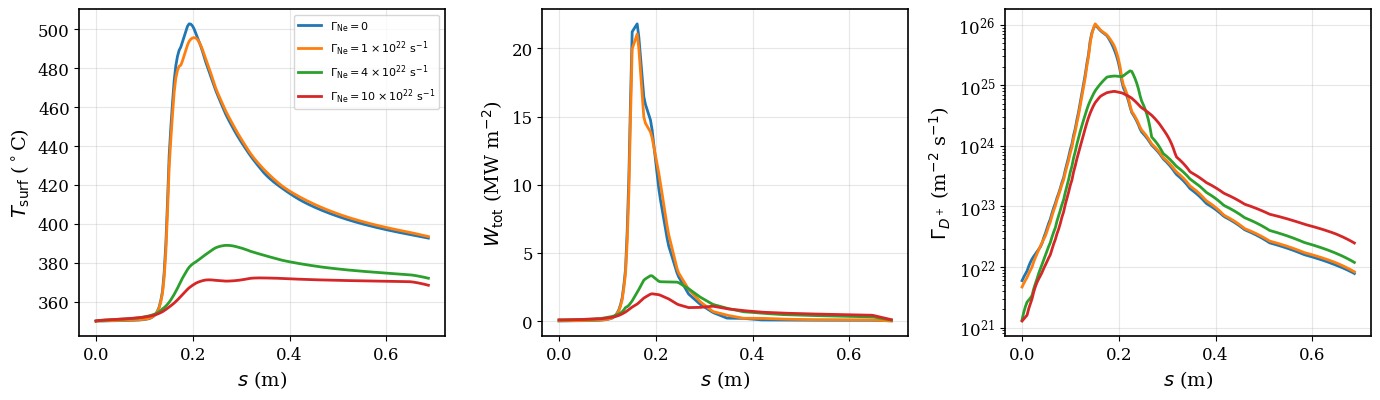

In [414]:
def ne_case_value(case):
    ne_tags = [part for part in case.split("_") if part.startswith("ne")]
    return int(ne_tags[0][2:]) if ne_tags else 0

def ne_case_label(case):
    val = ne_case_value(case)
    if val == 0:
        return r"$\Gamma_{\mathrm{Ne}}=0$"
    return rf"$\Gamma_{{\mathrm{{Ne}}}}={val}\times 10^{{22}}\ \mathrm{{s^{{-1}}}}$"

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)

frames = {}
for case in SELECTED_CASES:
    csv_path = STRIP_DIR / f"{case}.strip.csv"
    if not csv_path.exists() or csv_path.stat().st_size == 0:
        print(f"missing or empty: {csv_path}")
        continue
    df = pd.read_csv(csv_path)
    frames[case] = df
    print(f"{case}: {len(df)} rows  cols={list(df.columns)}")

for case in sorted(frames, key=ne_case_value):
    df = frames[case]
    label = ne_case_label(case)
    axes[0].plot(df["s_m"], df["Tsurf_C"], lw=2, label=label)
    axes[1].plot(df["s_m"], df["Wtot_Wm2"] * 1e-6, lw=2, label=label)
    axes[2].semilogy(df["s_m"], df["Gamma_D_m2s"], lw=2, label=label)

axes[0].set_ylabel(r"$T_\mathrm{surf}$ ($^\circ$C)")
axes[1].set_ylabel(r"$W_\mathrm{tot}$ (MW m$^{-2}$)")
axes[2].set_ylabel(r"$\Gamma_{D^+}$ (m$^{-2}$ s$^{-1}$)")
for ax in axes:
    ax.set_xlabel(r"$s$ (m)")

for ax in axes:
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()


## Geometry, case-specific `.surf` files, and full OpenEdge runs

The divertor geometry is the same as in the original walkthrough. We reuse the same `divertor_slab.surf`, compute the front-face arc-length midpoints, and for each case we do a **two-stage OpenEdge workflow**:

1. first OpenEdge `run 0` with `fix surface/state/lm` and the case's `ld_tg_o.dat` to generate a fresh `<case>.strip.csv`,
2. build `divertor_slab_strip_<case>.surf` from that fresh strip output,
3. run a second OpenEdge case using the case-specific `.surf` for evaporation / adatom / sputtering while tracking droplets.

The full OpenEdge deck then reads:

- case-specific `plasma_<case>.h5`
- case-specific `divertor_slab_strip_<case>.surf`
- per-run `droplet.species`

and writes full `output/surf_flux.*` dumps for cross-case comparison.

## Droplet scenarios — literature mapping

Three distinct mass-loss mechanisms from the Miloshevsky / Coenen JNM
papers, mapped to representative Li droplet radii. The `SCENARIOS` list
in the next cell uses these values.

| Scenario | Mechanism | Li radius | Character | Source |
|---|---|---|---|---|
| **Mist** | Viscous-KH spray — short-λ instability at the plasma-melt interface; W λ_c ≈ 6 μm at μ_p ~ 10⁻⁵ kg/(m·s), ΔV ~ 10 km/s | **~10 μm** | continuous, fine spray, high number flux | Miloshevsky & Hassanein, *JNM* **438**, S155 (2013), Fig. 2 blue curve |
| **Droplet** | Capillary breakup — wave peaks pinch off at the most-unstable wavelength | **~100 μm** | intermittent, moderate flux; "ligaments and large droplets" regime observed at TEXTOR | Shi & Miloshevsky, *JNM* **412**, 123 (2011); Coenen et al., *JNM* **415**, S78 (2011) |
| **Ligament** | Inviscid-KH splashing — long-λ hydrodynamic mode, ΔV ~ 100 km/s, λ ~ 1–5 mm in W | **~1–2.5 mm** | rare large splashes; low number flux but huge mass per droplet (ELM / disruption regime) | Miloshevsky & Hassanein, *JNM* **438**, S155 (2013), Fig. 2 black curve (inviscid limit) |

*Notes.* (1) Sizes are Li-scaled from W values via the dominant-wavelength
ratio √(σ_Li ρ_W / σ_W ρ_Li) ≈ 2.2 — a small correction. (2) `n_emit` is
held constant across scenarios for simulation tractability; the comparison
is "wall response to 10 droplets/step of radius _r_", not a mass-balanced
sweep. (3) Injection velocity is tuned per scenario to the expected
plasma-drag velocity.

References:
- G. Miloshevsky and A. Hassanein, *J. Nucl. Mater.* **438**, S155–S159 (2013).
- Y. Shi, G. Miloshevsky, A. Hassanein, *J. Nucl. Mater.* **412**, 123–128 (2011).
- J.W. Coenen, V. Philipps, S. Brezinsek et al., *J. Nucl. Mater.* **415**, S78–S82 (2011).


In [438]:
FULL_RUN_CASES = list(SELECTED_CASES)
NPROC = 4
WARMUP_STEPS = 2
MAIN_STEPS = 10000
SURF_DUMP_EVERY = 100

RHO_LI_LIQUID = 530.0
T_DROPLET_K = 773.15
RADIUS_M = 2.5e-3  # kept for backward compat; used as the "ligament" scenario

# --- Droplet scenarios (Miloshevsky & Hassanein 2013, JNM 438 S155) ---
# Three distinct mass-loss mechanisms, Li-scaled radii. n_emit is held
# constant across scenarios for simulation tractability; only radius +
# injection velocity vary. The comparison is therefore "wall response to
# 10 droplets/step at radius r", not a mass-balanced sweep.
SCENARIOS = [
    dict(name="mist",     label="Mist (viscous-KH spray)",
         radius_m=1.0e-5, n_emit=1000, vmin=5.0,  vmax=100.0,
         mech="Miloshevsky 2013 viscous-KH (Fig. 2 blue)"),
    dict(name="droplet",  label="Droplet (capillary breakup)",
         radius_m=1.0e-4, n_emit=1000, vmin=1.0,  vmax=30.0,
         mech="Shi & Miloshevsky 2011, JNM 412 capillary model"),
    dict(name="ligament", label="Ligament (inviscid-KH splash)",
         radius_m=2.5e-3, n_emit=1000, vmin=0.1,  vmax=2.0,
         mech="Miloshevsky 2013 inviscid-KH (Fig. 2 black)"),
]

# Flat list of (case, scenario) keys joined with "__". Downstream code iterates
# this in place of SELECTED_CASES; helper parses the components when needed.
FULL_RUN_KEYS = [f"{case}__{s['name']}"
                 for case in SELECTED_CASES
                 for s in SCENARIOS]

def parse_run_key(key):
    """Return (case_name, scenario_dict) for a composite run key."""
    case, scen_name = key.rsplit("__", 1)
    scen = next(s for s in SCENARIOS if s["name"] == scen_name)
    return case, scen


def parse_surf_points_lines(path):
    pts = {}
    lines = []
    section = None
    for raw in Path(path).read_text().splitlines():
        s = raw.strip()
        if not s or s.startswith("#"):
            continue
        lower = s.lower()
        if lower == "points":
            section = "points"
            continue
        if lower == "lines":
            section = "lines"
            continue
        if not s[0].isdigit():
            continue
        parts = s.split()
        if section == "points":
            pts[int(parts[0])] = (float(parts[1]), float(parts[2]))
        elif section == "lines":
            lines.append((int(parts[0]), int(parts[1]), int(parts[2])))
    return pts, lines

def build_front_arc_midpoints(surf_path, n_front=199):
    pts, lines = parse_surf_points_lines(surf_path)
    x_mid = []
    y_mid = []
    s_mid = []
    s_acc = 0.0
    for lid, p1, p2 in sorted(lines):
        if lid > n_front:
            break
        x1, y1 = pts[p1]
        x2, y2 = pts[p2]
        seg_len = float(np.hypot(x2 - x1, y2 - y1))
        x_mid.append(0.5 * (x1 + x2))
        y_mid.append(0.5 * (y1 + y2))
        s_mid.append(s_acc + 0.5 * seg_len)
        s_acc += seg_len
    return np.asarray(x_mid), np.asarray(y_mid), np.asarray(s_mid)

X_MID_RUN, Y_MID_RUN, S_MID_RUN = build_front_arc_midpoints(SHARED_SURF)
print(f"front-arc segment midpoints: {len(S_MID_RUN)}")

def write_case_strip_surf(case, n_front=199):
    strip_csv = STRIP_DIR / f"{case}.strip.csv"
    df = pd.read_csv(strip_csv)
    # Map strip CSV -> OE surf segments by physical (R, Z), not by arc-length.
    # The strip CSV parameterizes s_m starting from the bottom of the slab
    # while the surf file numbers lines from the top, so np.interp on s_m
    # would paint the strike-line value onto the wrong segments.
    from scipy.spatial import cKDTree
    tree   = cKDTree(df[["R_m", "Z_m"]].values)
    _, idx = tree.query(np.column_stack([X_MID_RUN, Y_MID_RUN]))
    t_seg  = df["Tsurf_C"].values[idx]
    g_seg  = df["Gamma_D_m2s"].values[idx]
    surf_out = SURF_DIR / f"divertor_slab_strip_{case}.surf"

    with SHARED_SURF.open() as f, surf_out.open("w") as g:
        g.write("# divertor_slab.surf with Tsurf_lm [degC] and Gamma_D_lm [m^-2 s^-1] columns\n")
        g.write(f"# case={case}, n_arc={n_front}, back-cap rows zero in both columns\n\n")
        in_lines = False
        for raw in f:
            s = raw.strip()
            if s.lower().startswith("lines"):
                in_lines = True
                g.write(raw)
                continue
            if not in_lines or not s or not s[0].isdigit():
                g.write(raw)
                continue
            lid, p1, p2 = s.split()[:3]
            lid = int(lid)
            if lid <= n_front:
                t_val = float(t_seg[lid - 1])
                g_val = float(g_seg[lid - 1])
            else:
                t_val, g_val = 0.0, 0.0
            g.write(f"{lid} {p1} {p2} {t_val:.6e} {g_val:.6e}\n")

    return surf_out

def create_droplet_species(
    out_path,
    name,
    radius_m,
    rho_kg_m3,
    temp_K,
    *,
    rotdof=0,
    rotrel=0.0,
    vibdof=0,
    vibrel=0.0,
    vibtemp_K=0.0,
    specwt=1.0,
    charge=0.0,
    append=False,
):
    """Compute droplet mass from radius + bulk density and write a .species line."""
    AMU = 1.66053906660e-27
    mass_kg = (4.0 / 3.0) * math.pi * radius_m**3 * rho_kg_m3
    molwt_amu = mass_kg / AMU

    header = (
        "# Species data\n"
        "# ID    Molwt(amu)             Molmass(kg)            "
        "RotDof RotRel VibDof VibRel VibTemp(K) specwt charge radius(m) temp(K)\n"
    )
    line = (
        f"{name:<12s} {molwt_amu:.15e} {mass_kg:.15e} "
        f"{rotdof} {rotrel:g} {vibdof} {vibrel:g} {vibtemp_K:g} "
        f"{specwt:g} {charge:g} {radius_m:g} {temp_K:g}\n"
    )

    out_path = Path(out_path)
    mode = "a" if append else "w"
    with out_path.open(mode) as f:
        if not append:
            f.write(header)
            f.write(
                f"# auto-generated by create_droplet_species(): "
                f"r={radius_m*1e6:.2f} um, rho={rho_kg_m3:g} kg/m^3, T={temp_K:g} K\n"
            )
            f.write(
                "# RotDof/VibDof/VibTemp default to 0 (rigid sphere, no internal modes); "
                "override via kwargs if you want internal-energy DOFs\n"
            )
            f.write("# charge=0 initially; fix droplet/charge updates it during the run\n")
        f.write(line)

    print(
        f"{'appended' if append else 'wrote'} {out_path}: "
        f"{name} r={radius_m*1e6:.3f} um -> m={mass_kg:.3e} kg ({molwt_amu:.3e} amu)"
    )
    return mass_kg, molwt_amu

FULL_DECK_TEMPLATE = """shell       mkdir output

seed        12345
dimension   2
boundary    o o p
global      gridcut 0.0 comm/sort no
global      fnum 1e+14
timestep    5e-05

create_box  3.1 3.5 -3.8 -3.1 -0.05 0.05
create_grid 100 100 1
balance_grid rcb cell

species     droplet.species droplet
mixture     droplet droplet frac 1.0 nrho 1.0e19 temp 300.0 vstream 0.0 0.0 0.0

read_surf   {surf} custom Tsurf_lm float 0 custom Gamma_D_lm float 0 &
            invert group slab particle check
group div_front surf id <> 1 199
group div_back  surf id <> 200 202

surf_collide vac specular
surf_modify  slab collide vac

fix pd background file {plasma} static yes

compute cevap  surface/chemical/evaporation div_front tsurf Tsurf_lm sticking 1
compute cadat  surface/chemical/adatom      div_front tsurf Tsurf_lm dp_flux s_Gamma_D_lm
compute cpmiLi surface/physical/sputter     div_front background pd &
               target Li projectiles D,Ne,Li us 1.0 iead auto static yes &
               projectile_slots 1 14 erosion_flux sputter_flux_species all

fix fdrop droplet/emit droplet div_front nevery 1 n {n_emit} perspecies no normal no vmin {vmin} vmax {vmax} angle cosine
fix fcharge droplet/charge   1 background pd ion_mass_amu 2.0 thermionic no mixture droplet
fix fdrag   droplet/drag     1 2.0 1 background pd model coulomb coulomb/lnlambda 10 &
                             gravity 0 -9.8 0 mixture droplet
fix fevap   droplet/evaporate 1 droplet background pd heatflux/scale 1.0 rocket_eta 0.5

fix devap_tot ave/time 100 1 100 f_fevap file output/droplet_evap_total.csv
dump dpart particle all 10 output/dump.txt id type x y z vx vy vz radius temp
dump dsurf surf div_front {surf_dump_every} output/surf_flux.* &
     id v1x v1y v2x v2y c_cevap c_cadat c_cpmiLi[*] &
     s_Tsurf_lm s_Gamma_D_lm

stats       1
stats_style step np
run {warmup_steps}

unfix  fdrop
variable npart equal np
fix halt_drops halt 100 v_npart <= 0

stats       100
run         {main_steps}
"""

def generate_strip_csv_for_case(case, strip_csv=None, run_dir=None):
    run_dir = Path(run_dir) if run_dir is not None else (STRIP_RUNS_DIR / case)
    run_dir.mkdir(parents=True, exist_ok=True)
    plasma_file = PLASMA_DIR / f"plasma_{case}.h5"
    ld_tg_o_src = CASE_ROOT / case / "WLLD" / "ld_tg_o.dat"
    strip_csv = Path(strip_csv) if strip_csv is not None else (STRIP_DIR / f"{case}.strip.csv")
    deck_path = run_dir / "in.strip_case"

    stage_ld_tg_o(run_dir, ld_tg_o_src)
    deck_text = STRIP_DECK_TEMPLATE.format(
        surf=SHARED_SURF,
        plasma=plasma_file,
        strip_csv=strip_csv,
    )
    deck_path.write_text(deck_text)
    run_cmd(["mpirun", "-np", "1", str(OPENEDGE_BIN), "-in", deck_path.name], cwd=run_dir)
    return strip_csv

print(f"full-run cases (SELECTED): {SELECTED_CASES}")
print(f"droplet scenarios: {[s['name'] for s in SCENARIOS]}")
print(f"full-run keys (case x scenario): {len(FULL_RUN_KEYS)} total")
print(f"full-run output dir: {FULL_RUNS_DIR}")


front-arc segment midpoints: 199
full-run cases (SELECTED): ['P90MW_core_1e22_chi_0.3_D_0.1', 'P90MW_core_1e22_chi_0.3_D_0.1_ne1', 'P90MW_core_1e22_chi_0.3_D_0.1_ne4', 'P90MW_core_1e22_chi_0.3_D_0.1_ne10']
droplet scenarios: ['mist', 'droplet', 'ligament']
full-run keys (case x scenario): 12 total
full-run output dir: /Users/42d/OpenEdge/examples/test_tsurf_emission/jeremy_cases_generated/full_runs


In [439]:
n_emit

10

In [440]:
full_run_results = []

# Outer product: each (case, scenario) gets its own run_dir = "<case>__<scenario>"
# under FULL_RUNS_DIR. Strip/plasma files are shared per case (regenerated once
# per case via a cache). Downstream cells iterate FULL_RUN_KEYS in place of
# FULL_RUN_CASES; parse_run_key() pulls (case, scenario) back when needed.
_strip_cache = {}
for run_key in FULL_RUN_KEYS:
    case, scen = parse_run_key(run_key)
    run_dir = FULL_RUNS_DIR / run_key
    run_dir.mkdir(parents=True, exist_ok=True)

    plasma_file = PLASMA_DIR / f"plasma_{case}.h5"
    if case not in _strip_cache:
        strip_stage_dir = STRIP_RUNS_DIR / case
        _strip_cache[case] = generate_strip_csv_for_case(
            case,
            strip_csv=STRIP_DIR / f"{case}.strip.csv",
            run_dir=strip_stage_dir,
        )
    strip_csv = _strip_cache[case]
    surf_file = write_case_strip_surf(case)

    species_path = run_dir / "droplet.species"
    deck_path = run_dir / "in.oedge_case"

    create_droplet_species(
        species_path,
        name="droplet",
        radius_m=scen["radius_m"],
        rho_kg_m3=RHO_LI_LIQUID,
        temp_K=T_DROPLET_K,
    )

    deck_text = FULL_DECK_TEMPLATE.format(
        surf=surf_file,
        plasma=plasma_file,
        surf_dump_every=SURF_DUMP_EVERY,
        warmup_steps=WARMUP_STEPS,
        main_steps=MAIN_STEPS,
        n_emit=scen["n_emit"],
        vmin=scen["vmin"],
        vmax=scen["vmax"],
    )
    deck_path.write_text(deck_text)

    print(f"\n--- {run_key}  (r={scen['radius_m']:.1e} m, n={scen['n_emit']}, v={scen['vmin']}..{scen['vmax']} m/s) ---")
    run_cmd(["mpirun", "-np", str(NPROC), str(OPENEDGE_BIN), "-in", deck_path.name], cwd=run_dir)

    output_dir = run_dir / "output"
    surf_files = sorted(output_dir.glob("surf_flux.*"))
    full_run_results.append({
        "key": run_key,
        "case": case,
        "scenario": scen["name"],
        "radius_m": scen["radius_m"],
        # "run_dir": str(run_dir),
        # "strip_csv": str(strip_csv),
        # "surf_file": str(surf_file),
        # "plasma_h5": str(plasma_file),
        # "surf_flux_files": len(surf_files),
        # "dump_txt": (output_dir / "dump.txt").exists(),
        "droplet_evap_total": (output_dir / "droplet_evap_total.csv").exists(),
    })

pd.DataFrame(full_run_results)


+ mpirun -np 1 /Users/42d/OpenEdge/build/src/spa_mac_mpi -in in.strip_case
SPARTA-OPENDGE (20 Jan 2025)
Running on 1 MPI task(s)
Created orthogonal box = (3.1 -3.8 -0.05) to (3.5 -3.1 0.05)
Created 10000 child grid cells
  CPU time = 0.000895 secs
  create/ghost percent = 43.0168 56.9832
Balance grid migrated 0 cells
  CPU time = 0.000627 secs
  reassign/sort/migrate/ghost percent = 21.0526 1.5949 8.77193 68.5805
Reading surface file ...
  202 lines
  3.38162 3.48677 xlo xhi
  -3.77748 -3.1105 ylo yhi
  0 0 zlo zhi
  0.00338702 min line length
  242 0 = cells overlapping surfs, overlap cells with unmarked corner pts
  9688 70 242 = cells outside/inside/overlapping surfs
  242 = surf cells with 1,2,etc splits
  0.274664159760013 0.27466415976 = cell-wise and global flow volume
  CPU time = 0.001395 secs
  read/check/sort/surf2grid/ghost/inout/particle percent = 9.82079 2.86738 4.37276 51.0394 31.8996 13.5484 0
  surf2grid time = 0.000712 secs
  map/comm1/comm2/comm3/comm4/split percent 

,key,case,scenario,radius_m,droplet_evap_total
0,P90MW_core_1e22_chi_0.3_D_0.1__mist,P90MW_core_1e22_chi_0.3_D_0.1,mist,0.00001,True
1,P90MW_core_1e22_chi_0.3_D_0.1__droplet,P90MW_core_1e22_chi_0.3_D_0.1,droplet,0.00010,True
2,P90MW_core_1e22_chi_0.3_D_0.1__ligament,P90MW_core_1e22_chi_0.3_D_0.1,ligament,0.00250,True
3,P90MW_core_1e22_chi_0.3_D_0.1_ne1__mist,P90MW_core_1e22_chi_0.3_D_0.1_ne1,mist,0.00001,True
4,P90MW_core_1e22_chi_0.3_D_0.1_ne1__droplet,P90MW_core_1e22_chi_0.3_D_0.1_ne1,droplet,0.00010,True
5,P90MW_core_1e22_chi_0.3_D_0.1_ne1__ligament,P90MW_core_1e22_chi_0.3_D_0.1_ne1,ligament,0.00250,True
6,P90MW_core_1e22_chi_0.3_D_0.1_ne4__mist,P90MW_core_1e22_chi_0.3_D_0.1_ne4,mist,0.00001,True
7,P90MW_core_1e22_chi_0.3_D_0.1_ne4__droplet,P90MW_core_1e22_chi_0.3_D_0.1_ne4,droplet,0.00010,True
8,P90MW_core_1e22_chi_0.3_D_0.1_ne4__ligament,P90MW_core_1e22_chi_0.3_D_0.1_ne4,ligament,0.00250,True
9,P90MW_core_1e22_chi_0.3_D_0.1_ne10__mist,P90MW_core_1e22_chi_0.3_D_0.1_ne10,mist,0.00001,True


## Overlay OpenEdge wall-source profiles across cases

This compares the time-averaged `output/surf_flux.*` source terms from all selected cases.

<!-- ## Dominance framework: intrinsic wall processes vs droplets

For mechanism dominance, the clean comparison is between the **intrinsic wall-release channels**:

- $\Gamma_\mathrm{evap}(s)$
- $\Gamma_\mathrm{adatom}(s)$
- $\Gamma_\mathrm{sput}(s)$

all in units of m$^{-2}$ s$^{-1}$ along divertor arc length $s$.

We also define the local wall-total source

$$\Gamma_\mathrm{total,wall}(s) = \Gamma_\mathrm{evap}(s) + \Gamma_\mathrm{adatom}(s) + \Gamma_\mathrm{sput}(s).$$

Then the local fractions are

- $f_\mathrm{evap}(s) = \Gamma_\mathrm{evap}/\Gamma_\mathrm{total,wall}$
- $f_\mathrm{adatom}(s) = \Gamma_\mathrm{adatom}/\Gamma_\mathrm{total,wall}$
- $f_\mathrm{sput}(s) = \Gamma_\mathrm{sput}/\Gamma_\mathrm{total,wall}$

These are the right quantities for statements like:

- evaporation dominates near the hottest region,
- adatom release becomes competitive where $\Gamma_D$ is high but $T_\mathrm{surf}$ is moderate,
- physical sputtering is subdominant or localized.

For integrated budgets, we compute

- $Q_\mathrm{evap} = \int \Gamma_\mathrm{evap}(s)\, dA$
- $Q_\mathrm{adatom} = \int \Gamma_\mathrm{adatom}(s)\, dA$
- $Q_\mathrm{sput} = \int \Gamma_\mathrm{sput}(s)\, dA$

using a **2D-axisymmetric reduction with unit toroidal depth**, so here $dA = ds \times 1\,\mathrm{m}$.

Droplets are treated separately. Droplet evaporation is **not** an intrinsic wall-release channel; it depends on an assumed droplet injection model. Normalizing droplet evaporation by droplet surface area removes the trivial $R^2$ factor for a single droplet,

$$\dot N_\mathrm{evap,droplet} \sim A_\mathrm{drop}\, j_\mathrm{evap,drop}, \qquad A_\mathrm{drop} \sim 4\pi R^2,$$

but the total droplet contribution still depends on droplet multiplicity / area density / launch flux:

$$\dot N_\mathrm{evap,total\,drop} \sim N_\mathrm{drop}\, 4\pi R^2\, j_\mathrm{evap,drop}.$$

So droplets should be presented as **scenario studies**:

- low / medium / high droplet source,
- or a sweep in radius, launch rate, number flux, or mass flux,
- with cumulative Li released during flight taken from `droplet_evap_total.csv`.

Interpretation template:

- Among intrinsic wall-release channels, evaporation dominates in some cases while adatom release may become competitive in others; physical sputtering remains subdominant unless plasma conditions make it locally important.
- Droplet-mediated Li release can exceed these wall channels only under an **assumed** droplet source model. -->


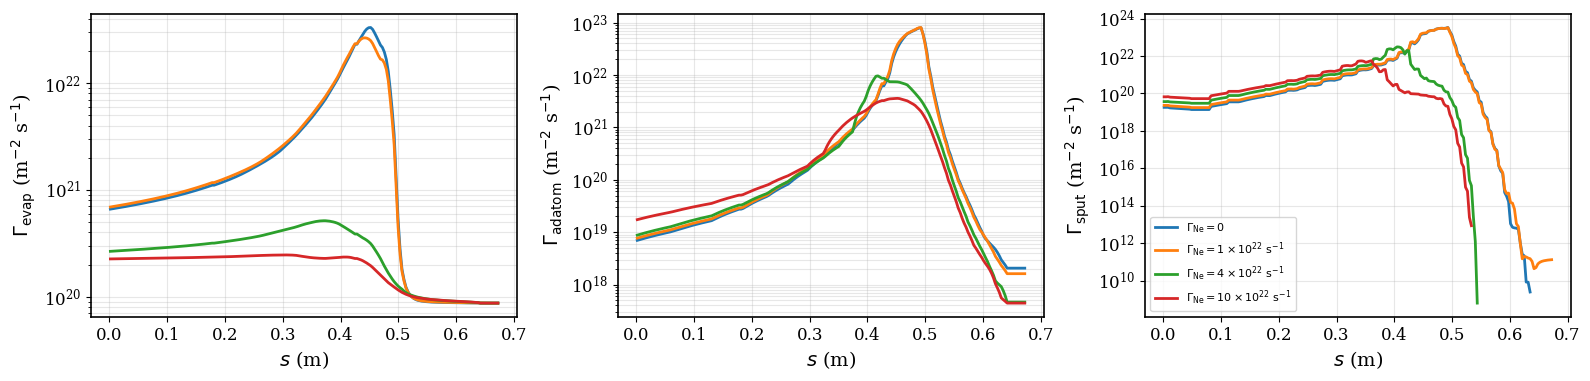

In [466]:
TOROIDAL_DEPTH_M = 1.0

def segment_widths_from_midpoints(s_mid):
    s_mid = np.asarray(s_mid, dtype=float)
    edges = np.empty(len(s_mid) + 1, dtype=float)
    edges[1:-1] = 0.5 * (s_mid[:-1] + s_mid[1:])
    edges[0] = s_mid[0] - (edges[1] - s_mid[0])
    edges[-1] = s_mid[-1] + (s_mid[-1] - edges[-2])
    return np.diff(edges)

def split_case_name(case):
    base_case, _, droplet_mode = case.partition("__")
    return base_case, droplet_mode

def ne_case_value(base_case):
    ne_tags = [part for part in base_case.split("_") if part.startswith("ne")]
    if not ne_tags:
        return 0
    return int(ne_tags[0][2:])

def short_case_label(base_case):
    ne_val = ne_case_value(base_case)
    if ne_val == 0:
        return r"$\Gamma_{\mathrm{Ne}}=0$"
    return rf"$\Gamma_{{\mathrm{{Ne}}}}={ne_val}\times 10^{{22}}\ \mathrm{{s^{{-1}}}}$"

FULL_DS_RUN = segment_widths_from_midpoints(S_MID_RUN)

wall_process_profiles_full = {}
wall_process_profiles = {}
for case in FULL_RUN_KEYS:
    base_case, _ = split_case_name(case)
    flux_glob = FULL_RUNS_DIR / case / "output" / "surf_flux.*"
    sids, data = plotter.read_surf_flux(str(flux_glob), columns=("c_cevap", "c_cadat", "c_cpmiLi[1]"))
    if len(sids) == 0:
        continue

    order = np.argsort(S_MID_RUN[sids - 1])
    s_seg = S_MID_RUN[sids - 1][order]
    ds_seg = FULL_DS_RUN[sids - 1][order]
    g_evap = np.asarray(data.get("c_cevap", np.zeros_like(s_seg)), dtype=float)[order]
    g_adat = np.asarray(data.get("c_cadat", np.zeros_like(s_seg)), dtype=float)[order]
    g_sput = np.asarray(data.get("c_cpmiLi[1]", np.zeros_like(s_seg)), dtype=float)[order]
    g_total = g_evap + g_adat + g_sput

    with np.errstate(divide="ignore", invalid="ignore"):
        f_evap = np.divide(g_evap, g_total, out=np.zeros_like(g_total), where=g_total > 0)
        f_adat = np.divide(g_adat, g_total, out=np.zeros_like(g_total), where=g_total > 0)
        f_sput = np.divide(g_sput, g_total, out=np.zeros_like(g_total), where=g_total > 0)

    prof = {
        "s": s_seg,
        "ds": ds_seg,
        "Gamma_evap": g_evap,
        "Gamma_adatom": g_adat,
        "Gamma_sput": g_sput,
        "Gamma_total_wall": g_total,
        "f_evap": f_evap,
        "f_adatom": f_adat,
        "f_sput": f_sput,
    }
    wall_process_profiles_full[case] = prof
    # Keep one curve per plasma case; scenario suffixes are redundant for this plot.
    wall_process_profiles[base_case] = prof

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
panel_map = [
    ("Gamma_evap", r"$\Gamma_\mathrm{evap}$ (m$^{-2}$ s$^{-1}$)", axes[0], True),
    ("Gamma_adatom", r"$\Gamma_\mathrm{adatom}$ (m$^{-2}$ s$^{-1}$)", axes[1], True),
    ("Gamma_sput", r"$\Gamma_\mathrm{sput}$ (m$^{-2}$ s$^{-1}$)", axes[2], True),
]

for base_case in sorted(wall_process_profiles, key=ne_case_value):
    prof = wall_process_profiles[base_case]
    label = short_case_label(base_case)
    for key, ylabel, ax, use_log in panel_map:
        y = np.asarray(prof[key], dtype=float)
        if use_log:
            y = np.where(y > 0, y, np.nan)
            ax.semilogy(prof["s"], y, lw=2, label=label)
        else:
            ax.plot(prof["s"], y, lw=2, label=label)
            ax.set_ylim(0.0, 1.05)
        ax.set_ylabel(ylabel)
        ax.set_xlabel(r"$s$ (m)")
        ax.grid(True, which="both", alpha=0.3)

axes[2].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


In [467]:
summary_rows = []

def split_case_name(case):
    base_case, _, droplet_mode = case.partition("__")
    droplet_mode = droplet_mode or "unspecified"
    ne_tags = [part for part in base_case.split("_") if part.startswith("ne")]
    base_label = ne_tags[0] if ne_tags else "ref"
    return base_case, base_label, droplet_mode

def base_sort_key(label):
    if label == "ref":
        return -1
    if label.startswith("ne"):
        try:
            return int(label[2:])
        except ValueError:
            return np.inf
    return np.inf

droplet_order = {"mist": 0, "droplet": 1, "ligament": 2, "unspecified": 3}
mode_list = ["mist", "droplet", "ligament"]

def droplet_radius_um(case):
    species_path = FULL_RUNS_DIR / case / "droplet.species"
    with open(species_path, "r") as fh:
        for line in fh:
            if line.startswith("droplet"):
                radius_m = float(line.split()[10])
                return radius_m * 1e6
    return np.nan

for case, prof in wall_process_profiles_full.items():
    base_case, base_label, droplet_mode = split_case_name(case)
    area_seg = prof["ds"] * TOROIDAL_DEPTH_M
    q_evap = np.nansum(prof["Gamma_evap"] * area_seg)
    q_adat = np.nansum(prof["Gamma_adatom"] * area_seg)
    q_sput = np.nansum(prof["Gamma_sput"] * area_seg)
    q_total = q_evap + q_adat + q_sput

    evap_csv = FULL_RUNS_DIR / case / "output" / "droplet_evap_total.csv"
    droplet_total = np.nan
    if evap_csv.exists() and evap_csv.stat().st_size > 0:
        arr = np.loadtxt(evap_csv, comments="#")
        arr = np.atleast_2d(arr)
        droplet_total = float(arr[-1, -1])

    summary_rows.append({
        "case": case,
        "base_case": base_case,
        "base_label": base_label,
        "droplet_mode": droplet_mode,
        "Q_evap": q_evap,
        "Q_adatom": q_adat,
        "Q_sput": q_sput,
        "Q_total_wall": q_total,
        "f_evap_int": q_evap / q_total if q_total > 0 else np.nan,
        "f_adatom_int": q_adat / q_total if q_total > 0 else np.nan,
        "f_sput_int": q_sput / q_total if q_total > 0 else np.nan,
        "droplet_evap_cumulative": droplet_total,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(
    by=["droplet_mode", "base_label"],
    key=lambda s: s.map(lambda x: droplet_order.get(x, 99)) if s.name == "droplet_mode" else s.map(base_sort_key),
).reset_index(drop=True)

display_cols = [
    "base_label", "Q_evap", "Q_adatom", "Q_sput",
    "f_evap_int", "f_adatom_int", "f_sput_int", "droplet_evap_cumulative",
]
fmt_map = {
    "Q_evap": "{:.3e}",
    "Q_adatom": "{:.3e}",
    "Q_sput": "{:.3e}",
    "f_evap_int": "{:.3f}",
    "f_adatom_int": "{:.3f}",
    "f_sput_int": "{:.3f}",
    "droplet_evap_cumulative": "{:.3e}",
}

for mode in mode_list:
    mode_df = summary_df[summary_df["droplet_mode"] == mode].copy()
    if mode_df.empty:
        continue
    display(mode_df[display_cols].style.format(fmt_map).set_caption(f"{mode} cases"))

,base_label,Q_evap,Q_adatom,Q_sput,f_evap_int,f_adatom_int,f_sput_int,droplet_evap_cumulative
0,ref,2.925e+21,3.774e+21,1.533e+22,0.133,0.171,0.696,3.279e+17
1,ne1,2.711e+21,3.878e+21,1.541e+22,0.123,0.176,0.700,3.284e+17
2,ne4,1.892e+20,8.055e+20,1.404e+21,0.079,0.336,0.585,3.280e+17
3,ne10,1.290e+20,4.368e+20,4.176e+20,0.131,0.444,0.425,3.287e+17


,base_label,Q_evap,Q_adatom,Q_sput,f_evap_int,f_adatom_int,f_sput_int,droplet_evap_cumulative
4,ref,2.925e+21,3.774e+21,1.533e+22,0.133,0.171,0.696,2.143e+20
5,ne1,2.711e+21,3.878e+21,1.541e+22,0.123,0.176,0.700,2.131e+20
6,ne4,1.892e+20,8.055e+20,1.404e+21,0.079,0.336,0.585,2.162e+20
7,ne10,1.290e+20,4.368e+20,4.176e+20,0.131,0.444,0.425,2.215e+20


,base_label,Q_evap,Q_adatom,Q_sput,f_evap_int,f_adatom_int,f_sput_int,droplet_evap_cumulative
8,ref,2.925e+21,3.774e+21,1.533e+22,0.133,0.171,0.696,1.459e+24
9,ne1,2.711e+21,3.878e+21,1.541e+22,0.123,0.176,0.700,1.464e+24
10,ne4,1.892e+20,8.055e+20,1.404e+21,0.079,0.336,0.585,1.309e+24
11,ne10,1.290e+20,4.368e+20,4.176e+20,0.131,0.444,0.425,1.427e+24


In [465]:
case = FULL_RUN_KEYS[0]

flux_glob = FULL_RUNS_DIR / case / "output" / "surf_flux.*"
sids, data = plotter.read_surf_flux(
  str(flux_glob),
  columns=(
      "c_cpmiLi[1]",
      "c_cpmiLi[2]", "c_cpmiLi[3]", "c_cpmiLi[4]", "c_cpmiLi[5]",
      "c_cpmiLi[6]", "c_cpmiLi[7]", "c_cpmiLi[8]", "c_cpmiLi[9]",
      "c_cpmiLi[10]", "c_cpmiLi[11]", "c_cpmiLi[12]",
      "c_cpmiLi[13]", "c_cpmiLi[14]", "c_cpmiLi[15]",
  )
)

species_keys = [k for k in data if k != "c_cpmiLi[1]"]
sum_species = np.zeros_like(np.asarray(data["c_cpmiLi[1]"], dtype=float))
for k in species_keys:
  sum_species += np.asarray(data[k], dtype=float)

print("max total       =", np.nanmax(data["c_cpmiLi[1]"]))
print("max sum_species =", np.nanmax(sum_species))
print("max ratio total/sum =", np.nanmax(np.asarray(data["c_cpmiLi[1]"]) / np.where(sum_species > 0, sum_species, np.nan)))



max total       = 3.31698e+23
max sum_species = 3.3169800098478776e+23
max ratio total/sum = 1.0000081296116308


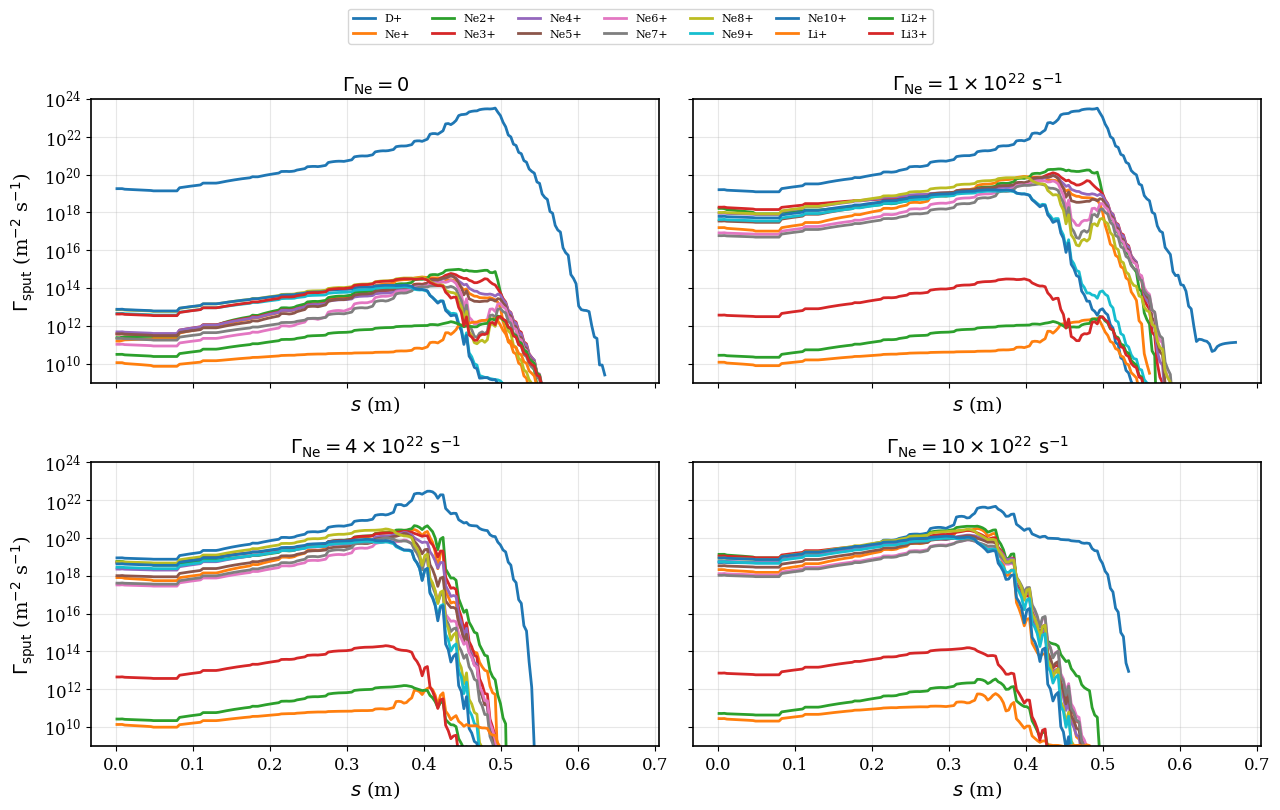

In [463]:
def ne_case_value(case):
    ne_tags = [part for part in case.split("_") if part.startswith("ne")]
    return int(ne_tags[0][2:]) if ne_tags else 0

def ne_case_label(case):
    val = ne_case_value(case)
    if val == 0:
        return r"$\Gamma_{\mathrm{Ne}}=0$"
    return rf"$\Gamma_{{\mathrm{{Ne}}}}={val}\times 10^{{22}}\ \mathrm{{s^{{-1}}}}$"

columns = (
    "c_cpmiLi[1]",
    "c_cpmiLi[2]", "c_cpmiLi[3]", "c_cpmiLi[4]", "c_cpmiLi[5]",
    "c_cpmiLi[6]", "c_cpmiLi[7]", "c_cpmiLi[8]", "c_cpmiLi[9]",
    "c_cpmiLi[10]", "c_cpmiLi[11]", "c_cpmiLi[12]",
    "c_cpmiLi[13]", "c_cpmiLi[14]", "c_cpmiLi[15]",
)

species_labels = {
    "c_cpmiLi[2]":  "D+",
    "c_cpmiLi[3]":  "Ne+",
    "c_cpmiLi[4]":  "Ne2+",
    "c_cpmiLi[5]":  "Ne3+",
    "c_cpmiLi[6]":  "Ne4+",
    "c_cpmiLi[7]":  "Ne5+",
    "c_cpmiLi[8]":  "Ne6+",
    "c_cpmiLi[9]":  "Ne7+",
    "c_cpmiLi[10]": "Ne8+",
    "c_cpmiLi[11]": "Ne9+",
    "c_cpmiLi[12]": "Ne10+",
    "c_cpmiLi[13]": "Li+",
    "c_cpmiLi[14]": "Li2+",
    "c_cpmiLi[15]": "Li3+",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, case in zip(axes, sorted(SELECTED_CASES, key=ne_case_value)):
    run_key = next(key for key in FULL_RUN_KEYS if key.startswith(case + "__"))
    flux_glob = FULL_RUNS_DIR / run_key / "output" / "surf_flux.*"
    sids, data = plotter.read_surf_flux(str(flux_glob), columns=columns)
    if len(sids) == 0:
        ax.set_title(ne_case_label(case) + "\nmissing surf_flux")
        ax.grid(True, which="both", alpha=0.3)
        continue

    order = np.argsort(S_MID_RUN[sids - 1])
    s_seg = S_MID_RUN[sids - 1][order]

    for key, label in species_labels.items():
        if key not in data:
            continue
        y = np.asarray(data[key], dtype=float)[order]
        y_pos = np.where(y > 0, y, np.nan)
        if np.all(np.isnan(y_pos)):
            continue
        ax.semilogy(s_seg, y_pos, lw=2, label=label)

    ax.set_title(ne_case_label(case))
    ax.set_xlabel(r"$s$ (m)")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_ylim(1e9,1e24)

axes[0].set_ylabel(r"$\Gamma_\mathrm{sput}$ (m$^{-2}$ s$^{-1}$)")
axes[2].set_ylabel(r"$\Gamma_\mathrm{sput}$ (m$^{-2}$ s$^{-1}$)")


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=7, fontsize=8, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


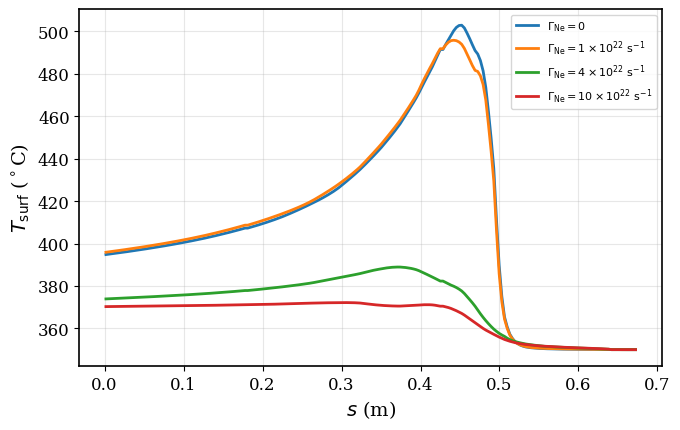

In [464]:
def ne_case_value(case):
    ne_tags = [part for part in case.split("_") if part.startswith("ne")]
    return int(ne_tags[0][2:]) if ne_tags else 0

def ne_case_label(case):
    val = ne_case_value(case)
    if val == 0:
        return r"$\Gamma_{\mathrm{Ne}}=0$"
    return rf"$\Gamma_{{\mathrm{{Ne}}}}={val}\times 10^{{22}}\ \mathrm{{s^{{-1}}}}$"

fig, ax = plt.subplots(figsize=(7, 4.5))

for case in sorted(SELECTED_CASES, key=ne_case_value):
    run_key = next(key for key in FULL_RUN_KEYS if key.startswith(case + "__"))
    flux_glob = FULL_RUNS_DIR / run_key / "output" / "surf_flux.*"
    sids, data = plotter.read_surf_flux(str(flux_glob), columns=("s_Tsurf_lm",))
    if len(sids) == 0 or "s_Tsurf_lm" not in data:
        continue

    order = np.argsort(S_MID_RUN[sids - 1])
    s_seg = S_MID_RUN[sids - 1][order]
    t_surf = np.asarray(data["s_Tsurf_lm"], dtype=float)[order]
    ax.plot(s_seg, t_surf, lw=2, label=ne_case_label(case))

ax.set_xlabel(r"$s$ (m)")
ax.set_ylabel(r"$T_\mathrm{surf}$ ($^\circ$C)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()


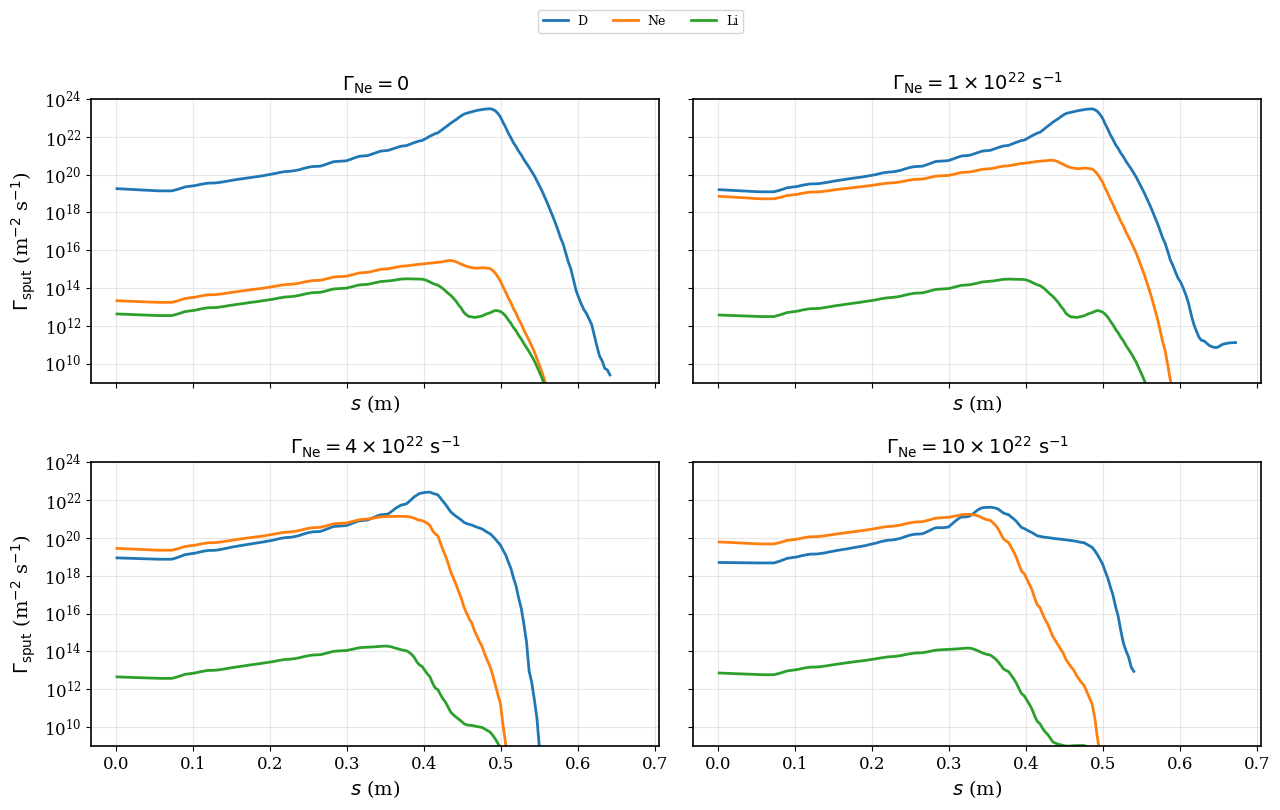

In [447]:
def ne_case_value(case):
    ne_tags = [part for part in case.split("_") if part.startswith("ne")]
    return int(ne_tags[0][2:]) if ne_tags else 0

def ne_case_label(case):
    val = ne_case_value(case)
    if val == 0:
        return r"$\Gamma_{\mathrm{Ne}}=0$"
    return rf"$\Gamma_{{\mathrm{{Ne}}}}={val}\times 10^{{22}}\ \mathrm{{s^{{-1}}}}$"

columns = (
    "c_cpmiLi[2]",
    "c_cpmiLi[3]", "c_cpmiLi[4]", "c_cpmiLi[5]", "c_cpmiLi[6]",
    "c_cpmiLi[7]", "c_cpmiLi[8]", "c_cpmiLi[9]", "c_cpmiLi[10]",
    "c_cpmiLi[11]", "c_cpmiLi[12]",
    "c_cpmiLi[13]", "c_cpmiLi[14]", "c_cpmiLi[15]",
)

element_groups = {
    "D": ("c_cpmiLi[2]",),
    "Ne": tuple(f"c_cpmiLi[{i}]" for i in range(3, 13)),
    "Li": ("c_cpmiLi[13]", "c_cpmiLi[14]", "c_cpmiLi[15]"),
}

SMOOTH_WINDOW = 5

def smooth_positive_log(y, window=SMOOTH_WINDOW):
    y = np.asarray(y, dtype=float)
    y_pos = np.where(y > 0, y, np.nan)
    if window <= 1 or np.all(np.isnan(y_pos)):
        return y_pos
    kernel = np.ones(window, dtype=float)
    logy = np.log10(y_pos)
    valid = np.isfinite(logy).astype(float)
    logy_filled = np.where(np.isfinite(logy), logy, 0.0)
    numer = np.convolve(logy_filled, kernel, mode="same")
    denom = np.convolve(valid, kernel, mode="same")
    smooth_logy = np.divide(numer, denom, out=np.full_like(numer, np.nan), where=denom > 0)
    return np.power(10.0, smooth_logy)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, case in zip(axes, sorted(SELECTED_CASES, key=ne_case_value)):
    run_key = next(key for key in FULL_RUN_KEYS if key.startswith(case + "__"))
    flux_glob = FULL_RUNS_DIR / run_key / "output" / "surf_flux.*"
    sids, data = plotter.read_surf_flux(str(flux_glob), columns=columns)
    if len(sids) == 0:
        ax.set_title(ne_case_label(case) + "\nmissing surf_flux")
        ax.grid(True, which="both", alpha=0.3)
        continue

    order = np.argsort(S_MID_RUN[sids - 1])
    s_seg = S_MID_RUN[sids - 1][order]

    for label, keys in element_groups.items():
        y_sum = np.zeros_like(s_seg, dtype=float)
        found = False
        for key in keys:
            if key not in data:
                continue
            y_sum += np.asarray(data[key], dtype=float)[order]
            found = True
        if not found:
            continue
        y_pos = smooth_positive_log(y_sum)
        if np.all(np.isnan(y_pos)):
            continue
        ax.semilogy(s_seg, y_pos, lw=2, label=label)

    ax.set_title(ne_case_label(case))
    ax.set_xlabel(r"$s$ (m)")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_ylim(1e9, 1e24)

axes[0].set_ylabel(r"$\Gamma_\mathrm{sput}$ (m$^{-2}$ s$^{-1}$)")
axes[2].set_ylabel(r"$\Gamma_\mathrm{sput}$ (m$^{-2}$ s$^{-1}$)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


# Plotting Li source a la Lore & Islam  

In [448]:
!pwd

/Users/42d/OpenEdge/examples/test_tsurf_emission


In [449]:
SELECTED_CASES

['P90MW_core_1e22_chi_0.3_D_0.1',
 'P90MW_core_1e22_chi_0.3_D_0.1_ne1',
 'P90MW_core_1e22_chi_0.3_D_0.1_ne4',
 'P90MW_core_1e22_chi_0.3_D_0.1_ne10']

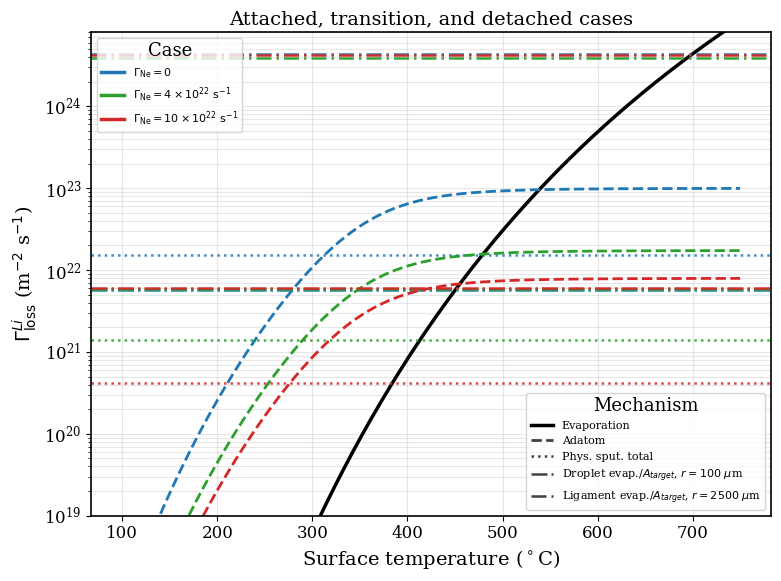

In [462]:
from evap_adatom import li_adatom_flux, li_evap_flux
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

t_c = np.linspace(100.0, 750.0, 401)
DT = 5.0e-5
FNUM = 1.0e14
DROPLET_MODES = ["droplet", "ligament"]
CASE_COLOR_MAP = {
  0: "tab:blue",
  4: "tab:green",
  10: "tab:red",
}
MECH_STYLE_MAP = {
  "adatom": "--",
  "sputter": ":",
  "droplet": "-.",
  "ligament": (0, (6, 2, 1, 2)),
}

def ne_case_value(case):
  ne_tags = [part for part in case.split("_") if part.startswith("ne")]
  return int(ne_tags[0][2:]) if ne_tags else 0

def ne_case_label(case):
  val = ne_case_value(case)
  if val == 0:
      return r"$\Gamma_{\mathrm{Ne}}=0$"
  return rf"$\Gamma_{{\mathrm{{Ne}}}}={val}\times 10^{{22}}\,\mathrm{{s^{{-1}}}}$"

plot_ne_values = {0, 4, 10}

rows = []
for case in sorted(SELECTED_CASES, key=ne_case_value):
  if ne_case_value(case) not in plot_ne_values:
      continue
  strip_csv = STRIP_DIR / f"{case}.strip.csv"
  df = pd.read_csv(strip_csv)

  prof = wall_process_profiles[case]
  area_seg = prof["ds"] * TOROIDAL_DEPTH_M
  target_area = float(np.nansum(area_seg))
  ne_val = ne_case_value(case)

  droplet_flux_by_mode = {}
  droplet_cum_by_mode = {}
  droplet_step_by_mode = {}
  droplet_radius_um_by_mode = {}
  droplet_rate_real_by_mode = {}
  for mode in DROPLET_MODES:
      run_key = f"{case}__{mode}"
      evap_csv = FULL_RUNS_DIR / run_key / "output" / "droplet_evap_total.csv"
      scen = next(s for s in SCENARIOS if s["name"] == mode)
      radius_m = float(scen["radius_m"])
      n_emit = int(scen["n_emit"])
      droplet_rate_real = n_emit * FNUM / DT

      droplet_evap_cum = np.nan
      droplet_flux_target = np.nan
      last_step = np.nan
      if evap_csv.exists() and evap_csv.stat().st_size > 0:
          arr = np.loadtxt(evap_csv, comments="#")
          arr = np.atleast_2d(arr)
          last_step = float(arr[-1, 0])
          droplet_evap_cum = float(arr[-1, 1])
          elapsed_s = last_step * DT
          if elapsed_s > 0 and target_area > 0:
              droplet_flux_target = droplet_evap_cum / (elapsed_s * target_area)
      droplet_flux_by_mode[mode] = droplet_flux_target
      droplet_cum_by_mode[mode] = droplet_evap_cum
      droplet_step_by_mode[mode] = last_step
      droplet_radius_um_by_mode[mode] = radius_m * 1.0e6
      droplet_rate_real_by_mode[mode] = droplet_rate_real

  rows.append({
      "case": case,
      "label": ne_case_label(case),
      "ne_value": ne_val,
      "Gamma_D_max": float(df["Gamma_D_m2s"].max()),
      "Tsurf_max_C": float(df["Tsurf_C"].max()),
      "Gamma_sput_max": float(np.nanmax(prof["Gamma_sput"])),
      "Q_sput_total": float(np.nansum(prof["Gamma_sput"] * area_seg)),
      "target_area": target_area,
      "droplet_flux_by_mode": droplet_flux_by_mode,
      "droplet_cum_by_mode": droplet_cum_by_mode,
      "droplet_step_by_mode": droplet_step_by_mode,
      "droplet_radius_um_by_mode": droplet_radius_um_by_mode,
      "droplet_rate_real_by_mode": droplet_rate_real_by_mode,
  })

case_df = pd.DataFrame(rows).sort_values("ne_value").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))

ax.semilogy(
  t_c,
  li_evap_flux(t_c, sticking=1.0),
  color="k",
  lw=2.5,
  label="Evaporation",
)

for _, row in case_df.iterrows():
  color = CASE_COLOR_MAP[row["ne_value"]]
  ax.semilogy(
      t_c,
      li_adatom_flux(t_c, row["Gamma_D_max"]),
      color=color,
      lw=2,
      ls=MECH_STYLE_MAP["adatom"],
  )

  ax.axhline(
      row["Q_sput_total"],
      color=color,
      lw=1.8,
      ls=MECH_STYLE_MAP["sputter"],
      alpha=0.85,
  )

  for mode in DROPLET_MODES:
      droplet_flux_target = row["droplet_flux_by_mode"].get(mode, np.nan)
      if np.isfinite(droplet_flux_target):
          ax.axhline(
              droplet_flux_target,
              color=color,
              lw=1.8,
              ls=MECH_STYLE_MAP[mode],
              alpha=0.95,
          )

ax.grid(True, which="both", alpha=0.3)
ax.set_ylabel(r"$\Gamma^{Li}_\mathrm{loss}$ (m$^{-2}$ s$^{-1}$)")
ax.set_xlabel(r"Surface temperature ($^\circ$C)")
ax.set_title("Attached, transition, and detached cases")
case_handles = [
  Line2D([0], [0], color=CASE_COLOR_MAP[0], lw=2.5, label=r"$\Gamma_{\mathrm{Ne}}=0$"),
  Line2D([0], [0], color=CASE_COLOR_MAP[4], lw=2.5, label=r"$\Gamma_{\mathrm{Ne}}=4\times10^{22}\ \mathrm{s^{-1}}$"),
  Line2D([0], [0], color=CASE_COLOR_MAP[10], lw=2.5, label=r"$\Gamma_{\mathrm{Ne}}=10\times10^{22}\ \mathrm{s^{-1}}$"),
]
mech_handles = [
  Line2D([0], [0], color="k", lw=2.5, label="Evaporation"),
  Line2D([0], [0], color="0.25", lw=2.0, ls=MECH_STYLE_MAP["adatom"], label="Adatom"),
  Line2D([0], [0], color="0.25", lw=1.8, ls=MECH_STYLE_MAP["sputter"], label="Phys. sput. total"),
  Line2D([0], [0], color="0.25", lw=1.8, ls=MECH_STYLE_MAP["droplet"], label=r"Droplet evap./$A_{target}$, $r=100\ \mu$m"),
  Line2D([0], [0], color="0.25", lw=1.8, ls=MECH_STYLE_MAP["ligament"], label=r"Ligament evap./$A_{target}$, $r=2500\ \mu$m"),
]
leg_cases = ax.legend(handles=case_handles, loc="upper left", title="Case", fontsize=8)
ax.add_artist(leg_cases)
ax.legend(handles=mech_handles, loc="lower right", title="Mechanism", fontsize=8)
ax.set_ylim(1e19,8e24)
plt.tight_layout()
plt.show()

# display(case_df[[
#   "label", "Gamma_D_max", "Tsurf_max_C", "Gamma_sput_max", "Q_sput_total"
# ]])
# display(pd.DataFrame([{
#   "label": row["label"],
#   **{f"{mode}_evap_flux_target": row["droplet_flux_by_mode"].get(mode, np.nan) for mode in DROPLET_MODES},
#   **{f"{mode}_evap_cum": row["droplet_cum_by_mode"].get(mode, np.nan) for mode in DROPLET_MODES},
#   **{f"{mode}_last_step": row["droplet_step_by_mode"].get(mode, np.nan) for mode in DROPLET_MODES},
#   **{f"{mode}_radius_um": row["droplet_radius_um_by_mode"].get(mode, np.nan) for mode in DROPLET_MODES},
#   **{f"{mode}_drop_rate_real_s": row["droplet_rate_real_by_mode"].get(mode, np.nan) for mode in DROPLET_MODES},
#   "target_area": row["target_area"],
# } for _, row in case_df.iterrows()]))